In [ ]:
%autoreload 2

In [3]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
rcParams['font.size'] = 10

In [180]:
def plot_line(dfs):
    omr_stims = ['forward', 'left', 'right', 'backward']
    dot_stims = ['dot_l', 'dot_r']
    fig, ax = plt.subplots(len(omr_stims), len(dot_stims) * 3, figsize=(10, 20), facecolor = 'black')
    for omr_n, omr in enumerate(omr_stims):
        for dot_n, dot in enumerate(dot_stims):
            overlap = str([dot, omr])
            for n, (neuron_identity, color) in enumerate(zip([f'{overlap}_dotonly', f'{overlap}_gratingonly', f'{overlap}_both'],[utils.pink, utils.green, 'grey'])):
                ax_line = ax[omr_n, dot_n * 3 + n]
                for stim, linestyle in zip(['dot', 'grating', 'overlap'], [':', '--', '-']):
                    trace = dfs[(dfs.neuron_identity==neuron_identity) & (dfs.stim == stim)].drop(['neuron_identity', 'stim'], axis = 1).groupby('real_fish_id').mean()
                    std = np.std(np.diff(trace), axis = 0)[30:100]
                    std = np.divide(std, np.sqrt(len(dfs.real_fish_id.unique())))
                    trace = np.nanmean(trace, axis = 0)[30:100]
                    if stim == 'grating':
                        gtrace = np.diff(trace)#, [0] * 32+ [-0.02] * 5 + [0] * 32)
                    elif stim == 'dot':
                        dtrace = np.diff(trace)
                    elif stim == 'overlap':
                        pass
                        #ax_line.plot(np.add(gtrace, dtrace),#np.add(gtrace, dtrace),#
                        #             color = 'red', linewidth = 1, linestyle = ':', alpha = 1)

                    ax_line.plot(np.diff(trace), linestyle = linestyle, color = color, linewidth = 1)
                    ax_line.fill_between(x = range(len(trace)), y1 = trace + std, y2 = trace - std, color = color, alpha = 0.5, linewidth = 0)
                    ax_line.set_ylim([-0.05, 0.05])


                ax_line.set_facecolor('black')

    return fig

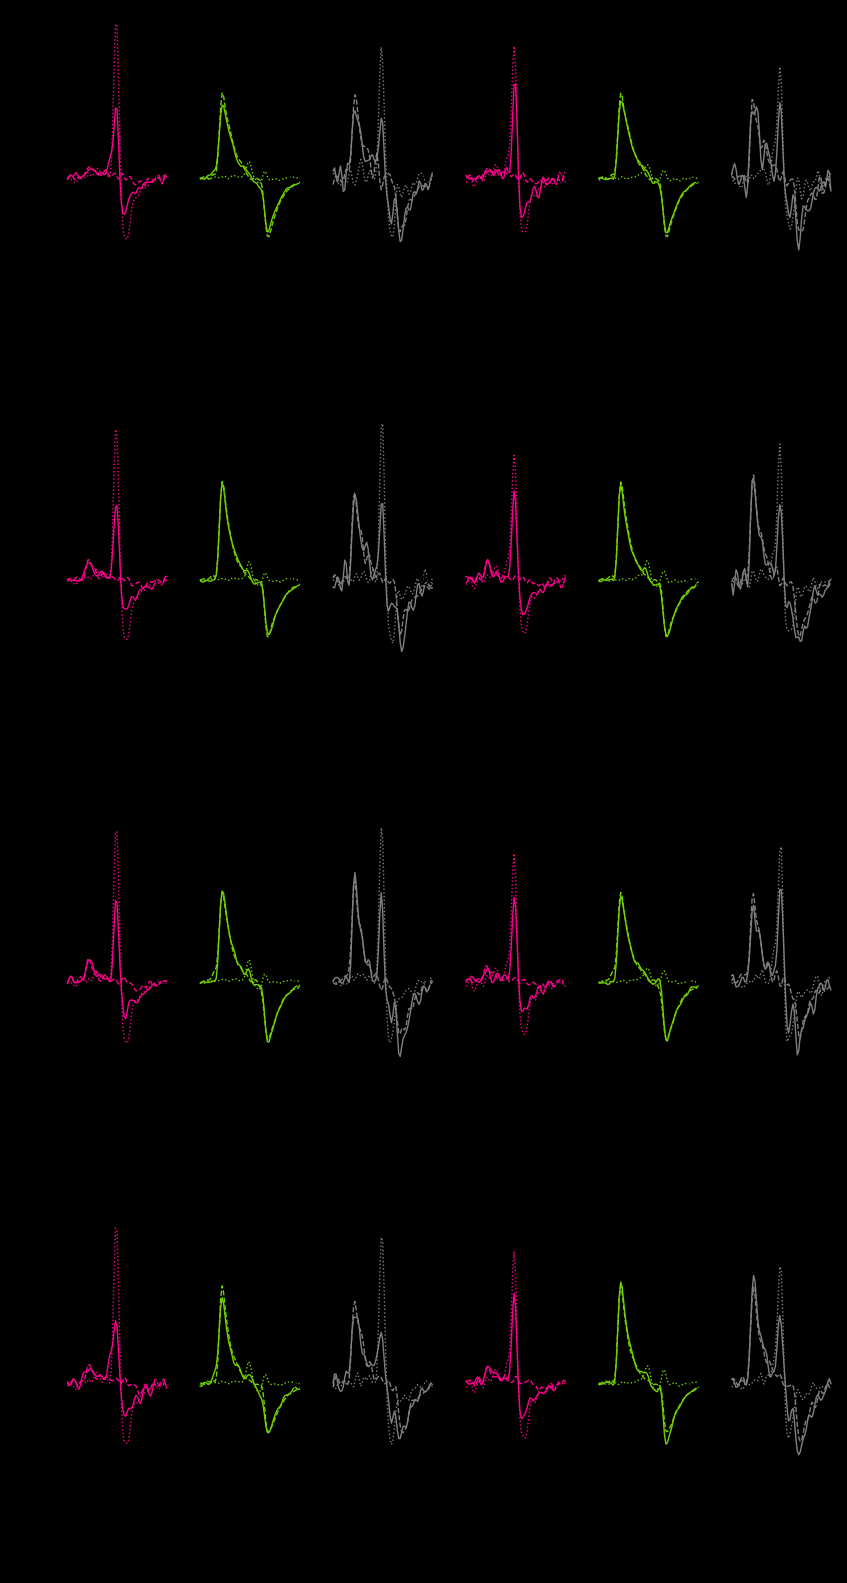

In [181]:
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]

dfs = []
for path in paths:
    f = pd.read_csv(path + f'//analyze_results//multiplexed_trace.csv', index_col = 0)
    f.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
    dfs.append(f)
dfs = pd.concat(dfs).reset_index(drop = True)
fig = plot_line(dfs)
#plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//multiplexed_trace_d.svg")
plt.show()
plt.close()